## Importación de librerías

In [1]:
#Tratamiento de datos
import pandas as pd

#Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración ruta
import sys
sys.path.append('../')

#Importar funciones de soporte
from src.soporte import analisis_rapido, eda, matriz_correlacion

## Carga de datos

In [2]:
data = pd.read_csv('../data/output/autorenew_limpio.csv')

In [3]:
data.head()

,name,price,vehicleType,yearOfRegistration,gearbox,powerCV,kilometer,fuelType,brand,notRepairedDamage
0,Golf_3_1.6,480,unknown,1993,manually,NaN,150000,petrol,volkswagen,unknown
1,A5_Sportback_2.7_Tdi,18300,coupe,2011,manually,187.0,125000,diesel,audi,yes
2,"Jeep_Grand_Cherokee_""Overland""",9800,suv,2004,automatic,161.0,125000,diesel,jeep,unknown
3,GOLF_4_1_4__3TÜRER,1500,small car,2001,manually,74.0,150000,petrol,volkswagen,no
4,Skoda_Fabia_1.4_TDI_PD_Classic,3600,small car,2008,manually,68.0,90000,diesel,skoda,no


## Objetivo del análisis

- Averiguar qué marcas son las mas vendidas, el rango de precios correspondiente y la antiguedad de los vehículos.
- Para evitar que vehiculos que tengan danos puedan sesgar el conjunto de datos y las conclusiones que saquemos, nos centraremos en el subconjunto de datos de vehiculos sin danos.

In [4]:
data['notRepairedDamage'].value_counts()

notRepairedDamage
no         258961
unknown     64571
yes         33291
Name: count, dtype: int64

In [5]:
df = data[data['notRepairedDamage'] == 'no'].copy()

Me quedo sólo con los que no tienen daños, entonces elimino columna.

In [6]:
df.drop(columns=['notRepairedDamage'], inplace=True)

## Análisis

In [7]:
df.head()

,name,price,vehicleType,yearOfRegistration,gearbox,powerCV,kilometer,fuelType,brand
3,GOLF_4_1_4__3TÜRER,1500,small car,2001,manually,74.0,150000,petrol,volkswagen
4,Skoda_Fabia_1.4_TDI_PD_Classic,3600,small car,2008,manually,68.0,90000,diesel,skoda
6,Peugeot_206_CC_110_Platinum,2200,convertible,2004,manually,108.0,150000,petrol,peugeot
9,Mazda_3_1.6_Sport,2000,unknown,2004,manually,104.0,150000,petrol,mazda
12,VW_PASSAT_1.9_TDI_131_PS_LEDER,2500,combi,2004,manually,129.0,150000,unknown,volkswagen


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 258961 entries, 3 to 356822
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   name                258961 non-null  object 
 1   price               258961 non-null  int64  
 2   vehicleType         258961 non-null  object 
 3   yearOfRegistration  258961 non-null  int64  
 4   gearbox             258961 non-null  object 
 5   powerCV             244341 non-null  float64
 6   kilometer           258961 non-null  int64  
 7   fuelType            258961 non-null  object 
 8   brand               258961 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 19.8+ MB


In [9]:
df.duplicated().sum()

8610

In [10]:
df.isna().mean().round(4) * 100

name                  0.00
price                 0.00
vehicleType           0.00
yearOfRegistration    0.00
gearbox               0.00
powerCV               5.65
kilometer             0.00
fuelType              0.00
brand                 0.00
dtype: float64

## Análisis

In [11]:
''' //Exportacion a SRC, ejecuto analisis_rapido al cominezo y lo borro//

    """
    Función que proporciona un análisis rápido de un DataFrame.
    Parámetros:
    df: DataFrame a analizar.
    n: Número de filas (por defecto = 5)
    
    """

    print(f"Las {n} primeras columnas son:")
    display(df.head(n))
    print("Información básica del DataFrame:")
    display(df.info())
  
    print(f"El número de duplicados es: {df.duplicated().sum()}")
    display(df.isna().mean().round(4) * 100)//

def analisis_rapido(df, n=5):

    """
    Función que proporciona un análisis rápido de un DataFrame.
    Parámetros:
    df: DataFrame a analizar.
    n: Número de filas (por defecto = 5)
    
    """

    print(f"Las {n} primeras columnas son:")
    display(df.head(n))
    print("Información básica del DataFrame:")
    display(df.info())
  
    print(f"El número de duplicados es: {df.duplicated().sum()}")
    display(df.isna().mean().round(4) * 100)
'''

' //Exportacion a SRC, ejecuto analisis_rapido al cominezo y lo borro//\n\n    """\n    Función que proporciona un análisis rápido de un DataFrame.\n    Parámetros:\n    df: DataFrame a analizar.\n    n: Número de filas (por defecto = 5)\n    \n    """\n\n    print(f"Las {n} primeras columnas son:")\n    display(df.head(n))\n    print("Información básica del DataFrame:")\n    display(df.info())\n  \n    print(f"El número de duplicados es: {df.duplicated().sum()}")\n    display(df.isna().mean().round(4) * 100)//\n\ndef analisis_rapido(df, n=5):\n\n    """\n    Función que proporciona un análisis rápido de un DataFrame.\n    Parámetros:\n    df: DataFrame a analizar.\n    n: Número de filas (por defecto = 5)\n    \n    """\n\n    print(f"Las {n} primeras columnas son:")\n    display(df.head(n))\n    print("Información básica del DataFrame:")\n    display(df.info())\n  \n    print(f"El número de duplicados es: {df.duplicated().sum()}")\n    display(df.isna().mean().round(4) * 100)\n'

In [12]:
analisis_rapido(df, 3)

Las 3 primeras columnas son:


,name,price,vehicleType,yearOfRegistration,gearbox,powerCV,kilometer,fuelType,brand
3,GOLF_4_1_4__3TÜRER,1500,small car,2001,manually,74.0,150000,petrol,volkswagen
4,Skoda_Fabia_1.4_TDI_PD_Classic,3600,small car,2008,manually,68.0,90000,diesel,skoda
6,Peugeot_206_CC_110_Platinum,2200,convertible,2004,manually,108.0,150000,petrol,peugeot


Información básica del DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 258961 entries, 3 to 356822
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   name                258961 non-null  object 
 1   price               258961 non-null  int64  
 2   vehicleType         258961 non-null  object 
 3   yearOfRegistration  258961 non-null  int64  
 4   gearbox             258961 non-null  object 
 5   powerCV             244341 non-null  float64
 6   kilometer           258961 non-null  int64  
 7   fuelType            258961 non-null  object 
 8   brand               258961 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 19.8+ MB


None

El número de duplicados es: 8610


name                  0.00
price                 0.00
vehicleType           0.00
yearOfRegistration    0.00
gearbox               0.00
powerCV               5.65
kilometer             0.00
fuelType              0.00
brand                 0.00
dtype: float64

Como hay pocos nulos en `powerCV` los elimino

In [13]:
#eliminamos filas con valores nulos, ya que no son muchas y no queremos perder información de otras columnas.
df.dropna(inplace=True)

In [14]:
df.columns

Index(['name', 'price', 'vehicleType', 'yearOfRegistration', 'gearbox',
       'powerCV', 'kilometer', 'fuelType', 'brand'],
      dtype='object')

## Columnas del dataset Limpio

- `name` : Nombre del anuncio, normalmente incluye la marca y el modelo del coche.
- `price` : Precio del coche en la moneda local (probablemente euros o dolares).
- `vehicleType` : Tipo de vehículo (sedán, SUV, compacto, etc.).
- `yearOfRegistration` : Año en el que se matriculo el coche.
- `gearbox` : Tipo de transmision (manual o automatica).
- `powerCV` : Potencia del coche en caballos de vapor (CV).
- `kilometer` : Kilometraje total del coche.
- `fuelType` : Tipo de combustible (gasolina, diésel, eléctrico, etc.).
- `brand` : Marca del coche.

## EDA

In [15]:
#Ponemos todo en una función y a SRC
""" def eda(df, n=2):
  num_cols = df.select_dtypes(include='number').columns
  cat_cols = df.select_dtypes(include=['object', 'category']).columns

  print("Variables numéricas:\n\n", num_cols)
  print("\nColumnas categóricas:\n\n", cat_cols)

  print("Veamos las estadísticas básicas:\n")

  display(df.describe().T.round(n))
  display(df.describe(include=['category', 'object']).T.round(n))

  for col in cat_cols:
    print(f" \n----------- Estamos analizando la columna: '{col}' -----------\n")
    print(f"Valores únicos: {df[col].unique()}\n")
    print("Frecuencias de los valores únicos de las categorías:")
    print(df[col].value_counts()) """

' def eda(df, n=2):\n  num_cols = df.select_dtypes(include=\'number\').columns\n  cat_cols = df.select_dtypes(include=[\'object\', \'category\']).columns\n\n  print("Variables numéricas:\n\n", num_cols)\n  print("\nColumnas categóricas:\n\n", cat_cols)\n\n  print("Veamos las estadísticas básicas:\n")\n\n  display(df.describe().T.round(n))\n  display(df.describe(include=[\'category\', \'object\']).T.round(n))\n\n  for col in cat_cols:\n    print(f" \n----------- Estamos analizando la columna: \'{col}\' -----------\n")\n    print(f"Valores únicos: {df[col].unique()}\n")\n    print("Frecuencias de los valores únicos de las categorías:")\n    print(df[col].value_counts()) '

Variables numéricas:

 Index(['price', 'yearOfRegistration', 'powerCV', 'kilometer'], dtype='object')

Columnas categóricas:

 Index(['name', 'vehicleType', 'gearbox', 'fuelType', 'brand'], dtype='object')
Veamos las estadísticas básicas:



,count,mean,std,min,25%,50%,75%,max
price,244341.0,7415.19,19312.58,101.0,1899.0,4300.0,9290.0,3895000.0
yearOfRegistration,244341.0,2004.11,6.78,1951.0,2000.0,2004.0,2009.0,2018.0
powerCV,244341.0,131.25,166.19,40.0,85.0,114.0,158.0,19726.0
kilometer,244341.0,122789.67,40411.55,5000.0,100000.0,150000.0,150000.0,150000.0


,count,unique,top,freq
name,244341,143490,BMW_318i,567
vehicleType,244341,8,unknown,78489
gearbox,244341,3,manually,184277
fuelType,244341,8,petrol,150553
brand,244341,40,volkswagen,51598


 
----------- Estamos analizando la columna: 'name' -----------

Valores únicos: ['GOLF_4_1_4__3TÜRER' 'Skoda_Fabia_1.4_TDI_PD_Classic'
 'Peugeot_206_CC_110_Platinum' ...
 'Alfa_Romeo_159_Jtdm_1.9_150_ps_13_600_km_top_voll'
 'Smart_smart_leistungssteigerung_100ps'
 'BMW_M135i_vollausgestattet_NP_52.720____Euro']

Frecuencias de los valores únicos de las categorías:


name
BMW_318i                                                567
Volkswagen_Golf_1.4                                     510
BMW_320i                                                458
BMW_316i                                                452
BMW_116i                                                364
                                                       ... 
Skoda_Octavia_1_6l_TDI_2011_Klima_AHK                     1
Seat_Altea_XL_2.0_TDI_DPF_DSG_Style_mit_grossem_Navi      1
Suzuki_Grande_Vitara_1_9_DDIS_Comfort                     1
Ford_Galaxy__2.3_Benzin                                   1
BMW_M135i_vollausgestattet_NP_52.720____Euro              1
Name: count, Length: 143490, dtype: int64

Countplots de las columnas categóricas:

La columna name tiene demasiadas categorías: 143490




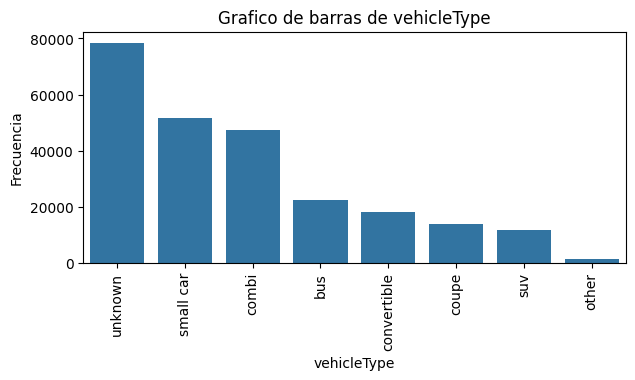

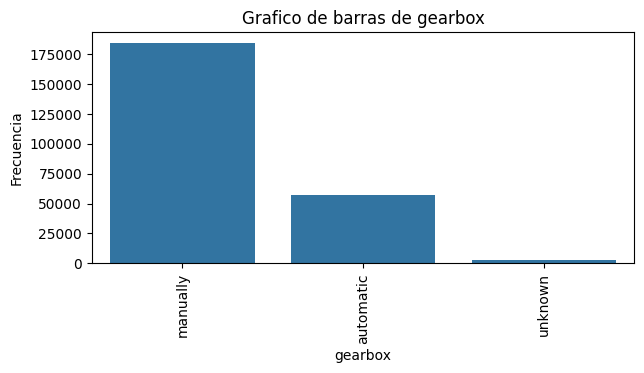

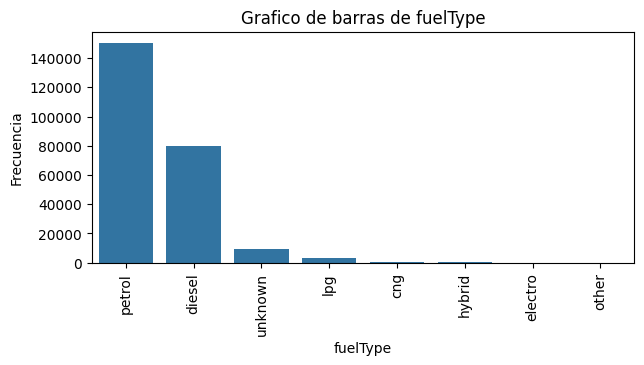

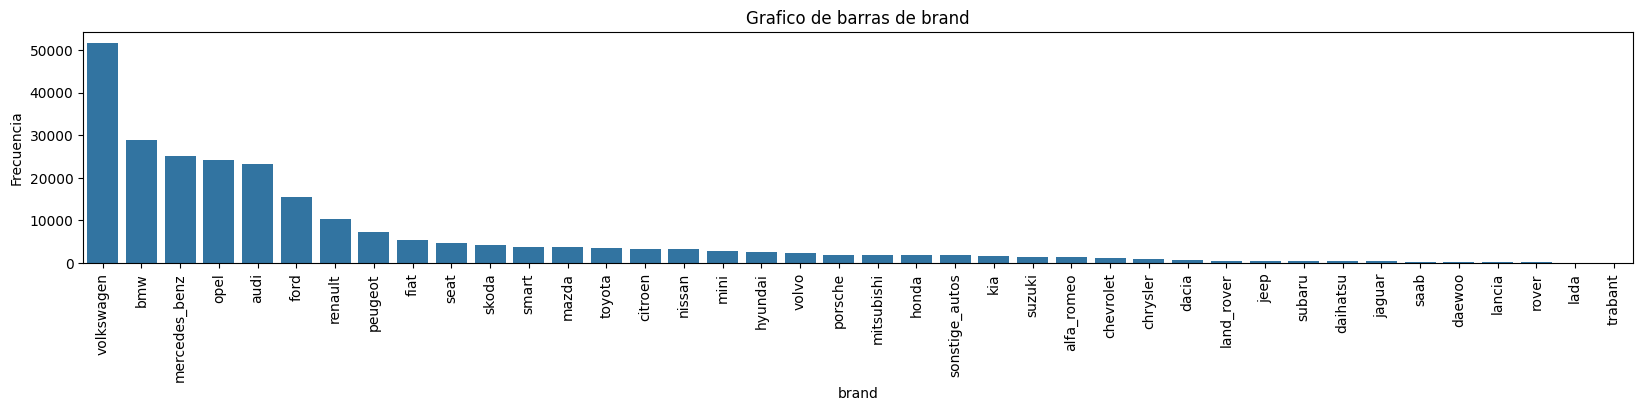

Histogramas:



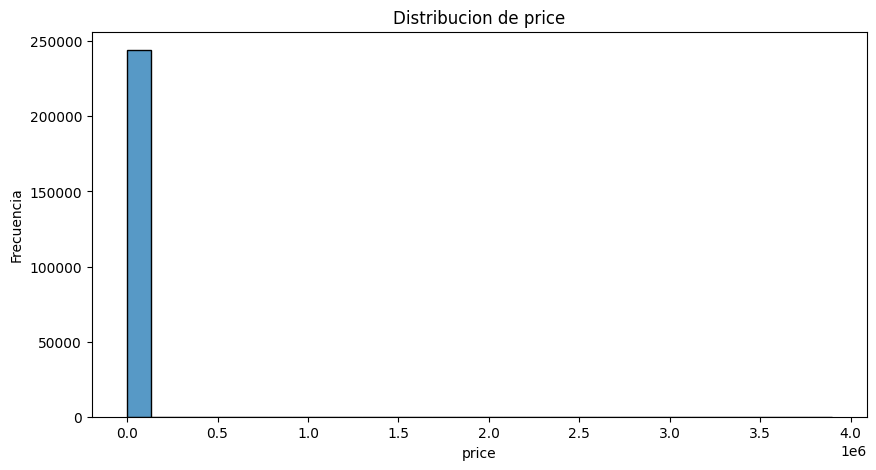

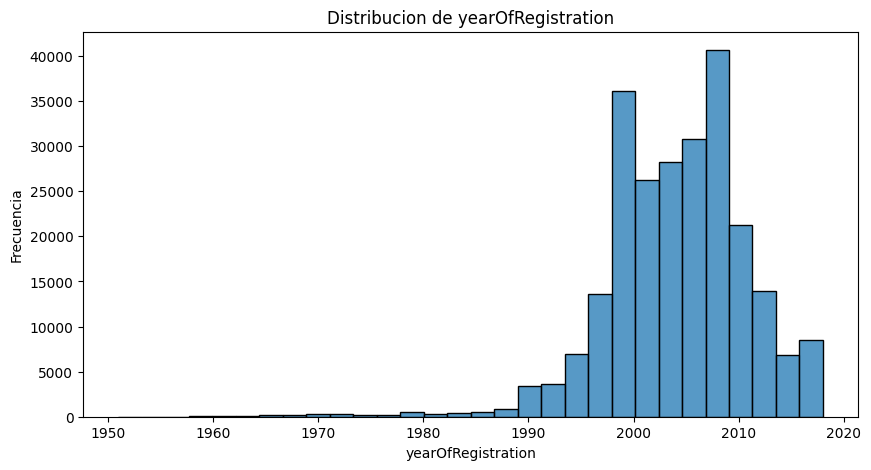

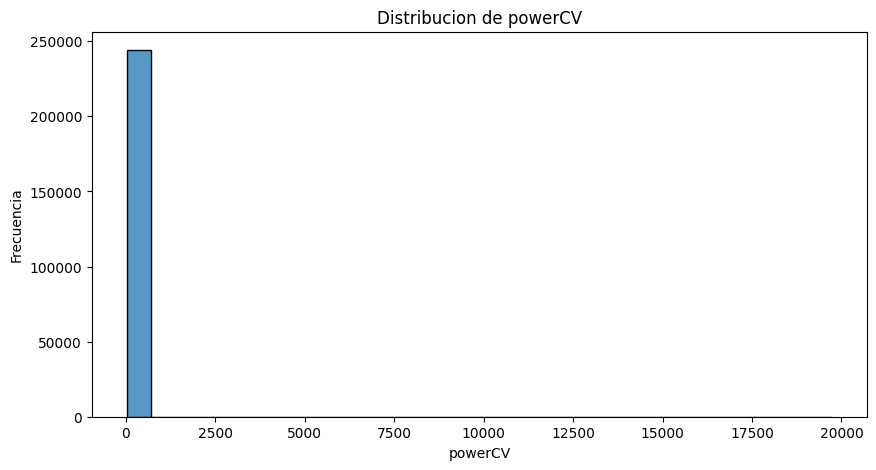

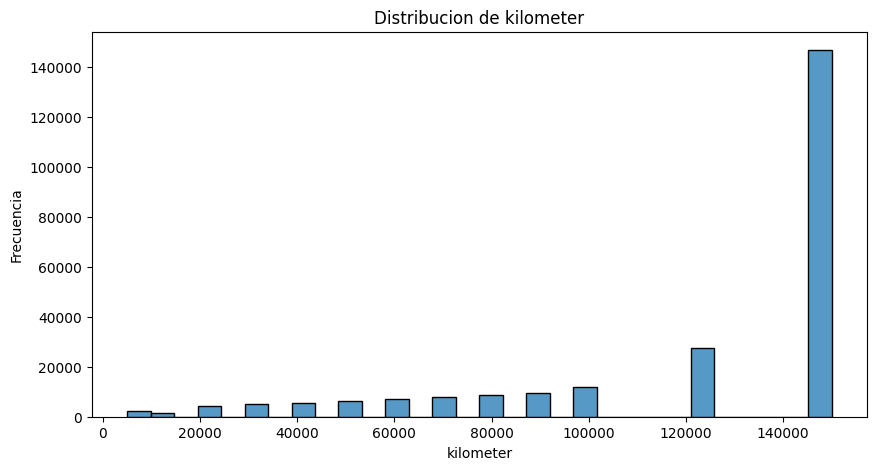

Vamos con los boxplots:



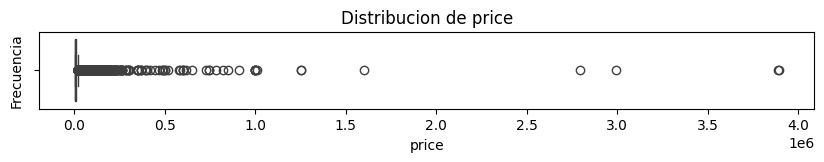

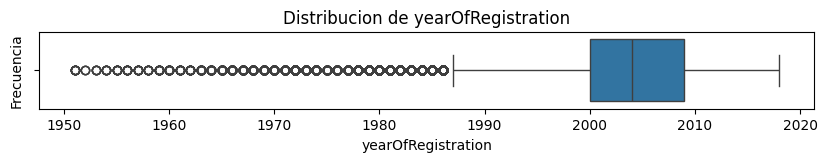

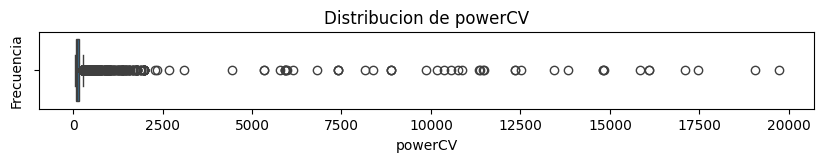

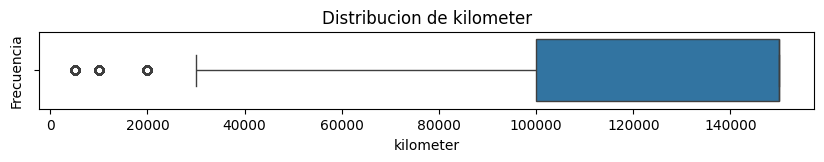

 
----------- Estamos analizando la columna: 'vehicleType' -----------

Valores únicos: ['small car' 'convertible' 'unknown' 'combi' 'suv' 'bus' 'coupe' 'other']

Frecuencias de los valores únicos de las categorías:


vehicleType
unknown        78489
small car      51478
combi          47369
bus            22339
convertible    18079
coupe          13665
suv            11564
other           1358
Name: count, dtype: int64

Countplots de las columnas categóricas:

La columna name tiene demasiadas categorías: 143490




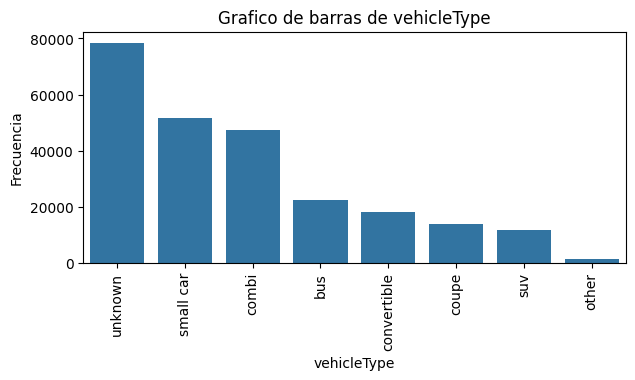

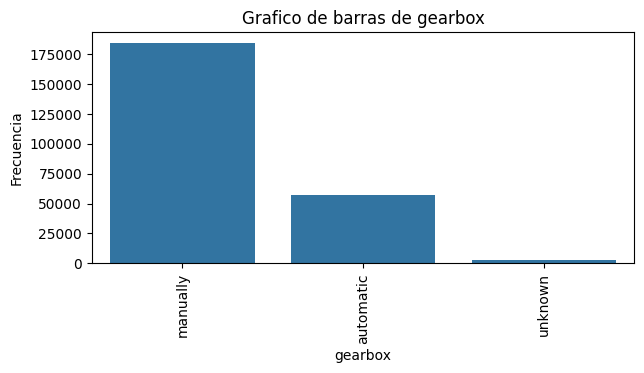

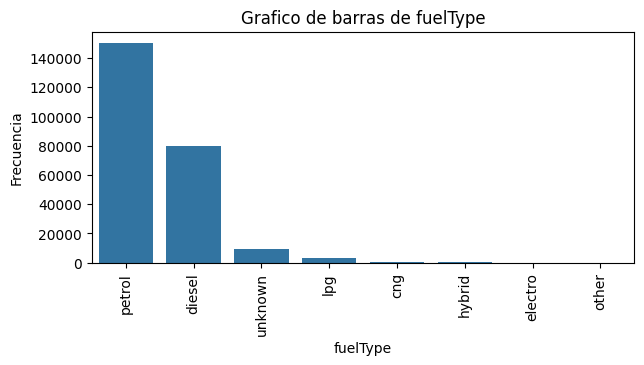

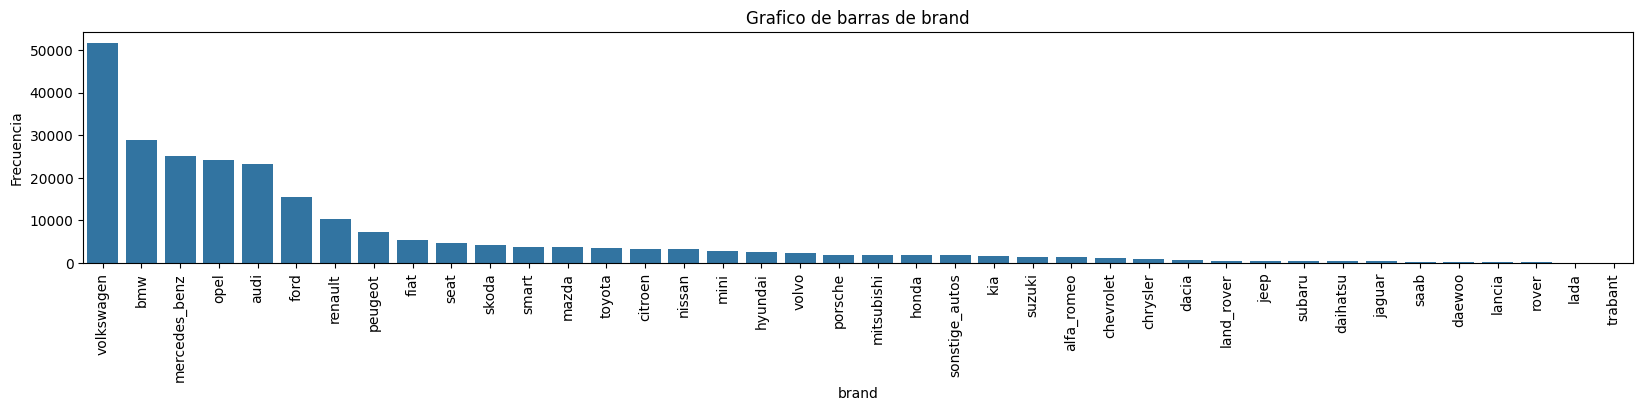

Histogramas:



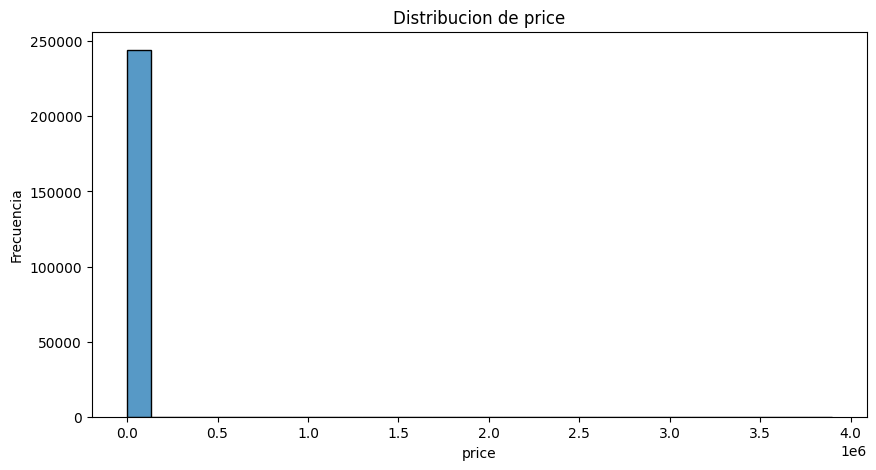

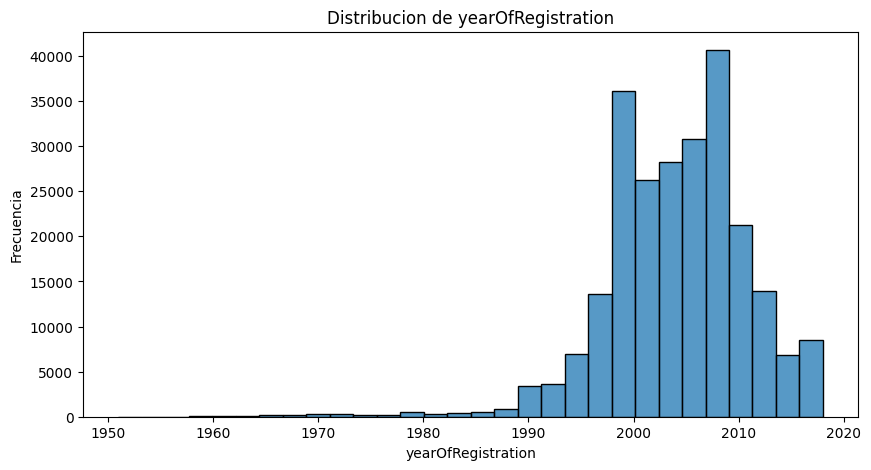

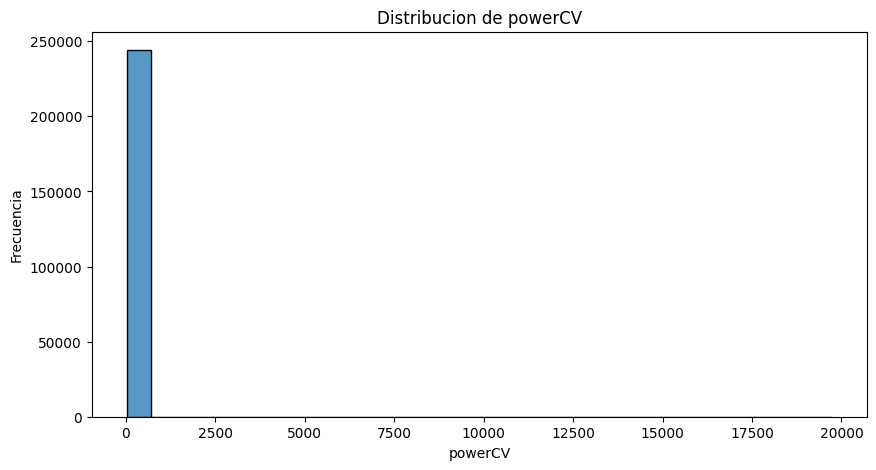

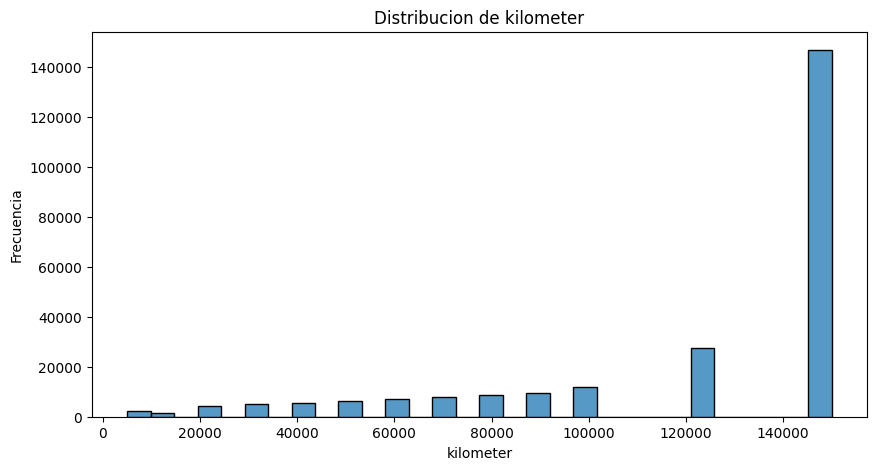

Vamos con los boxplots:



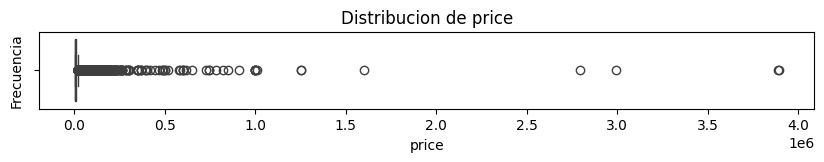

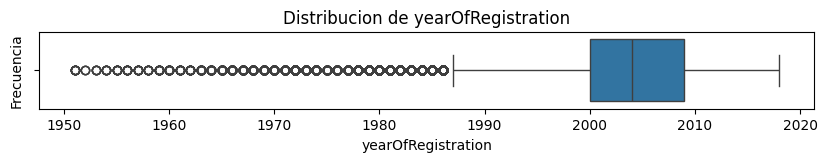

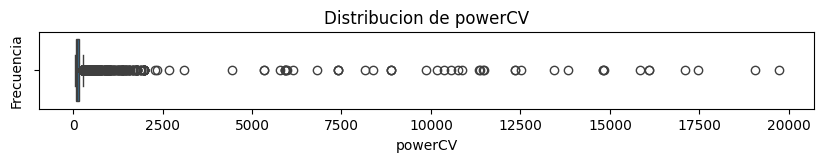

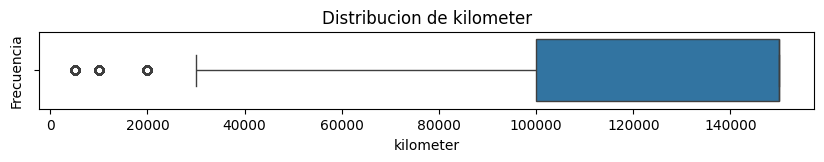

 
----------- Estamos analizando la columna: 'gearbox' -----------

Valores únicos: ['manually' 'automatic' 'unknown']

Frecuencias de los valores únicos de las categorías:


gearbox
manually     184277
automatic     57446
unknown        2618
Name: count, dtype: int64

Countplots de las columnas categóricas:

La columna name tiene demasiadas categorías: 143490




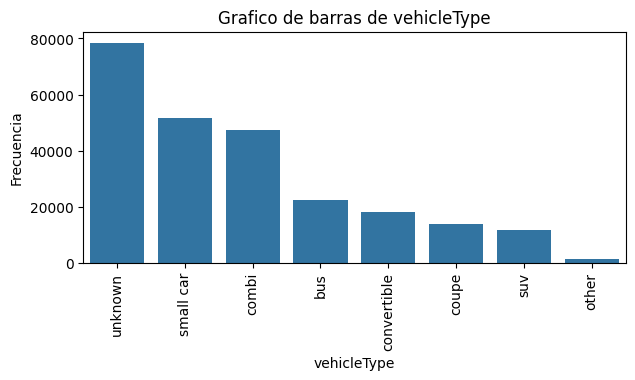

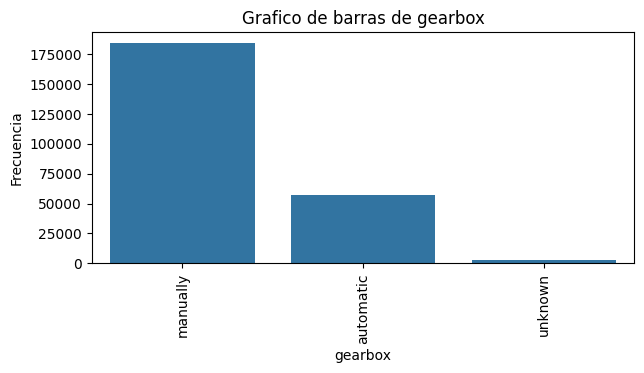

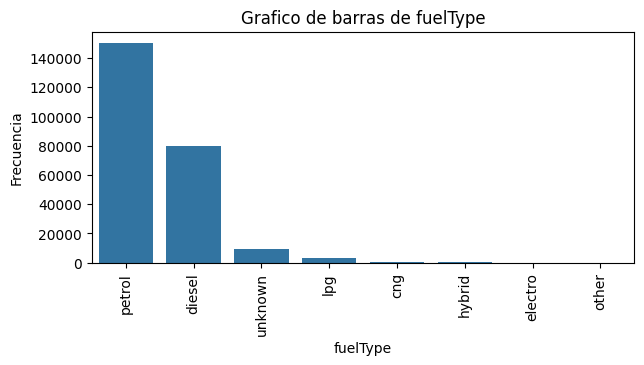

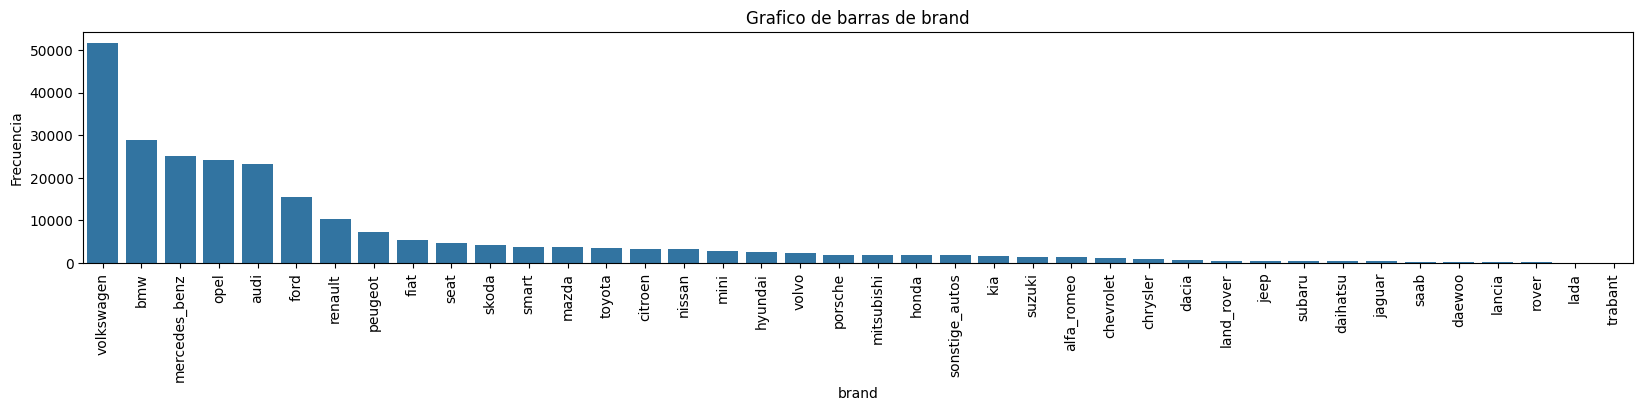

Histogramas:



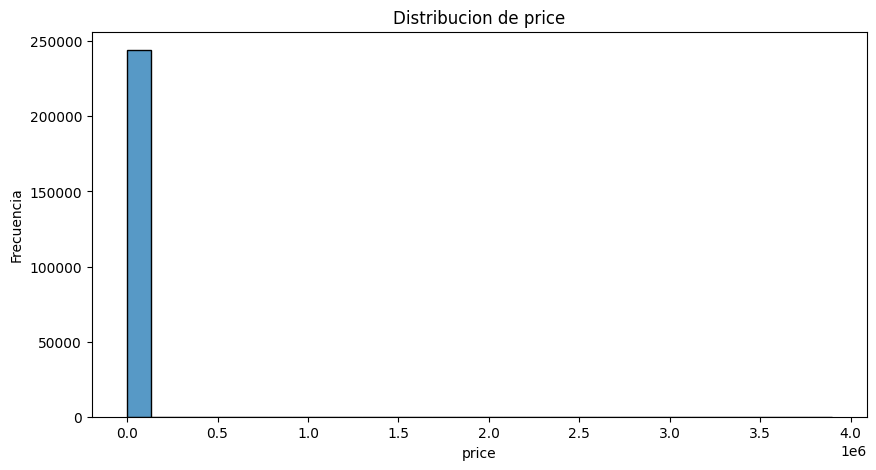

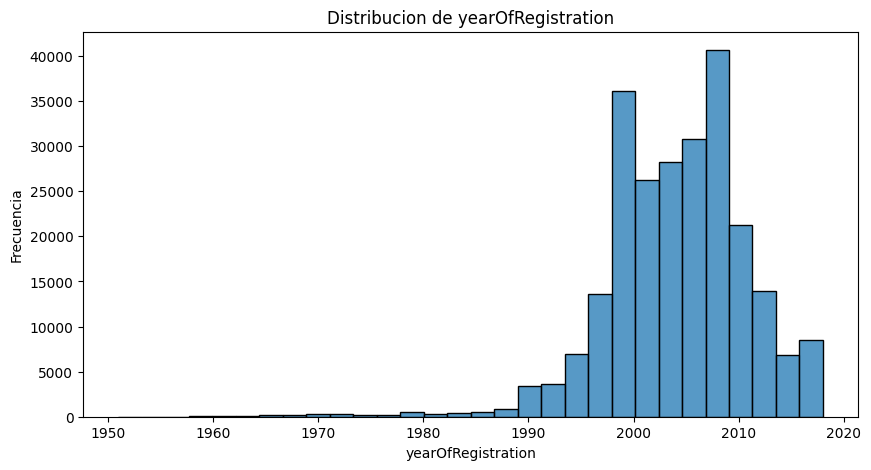

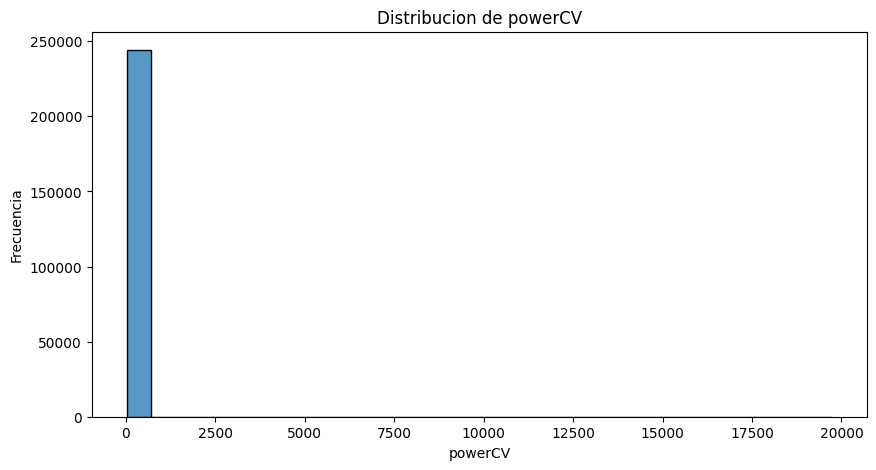

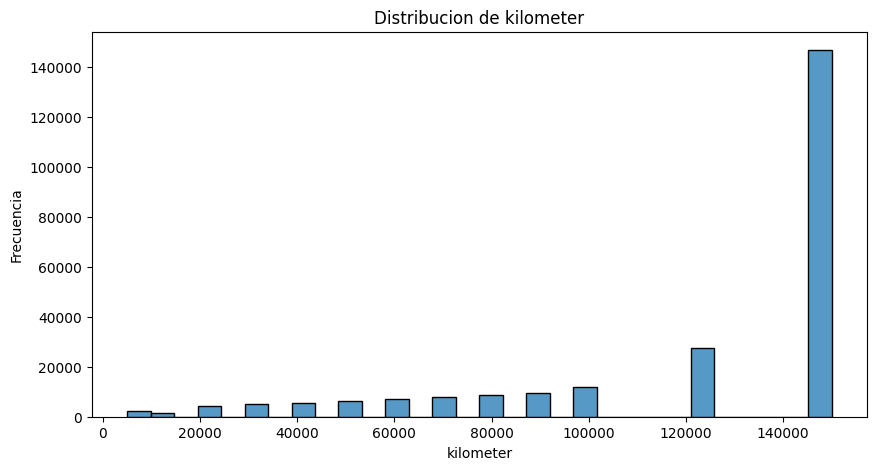

Vamos con los boxplots:



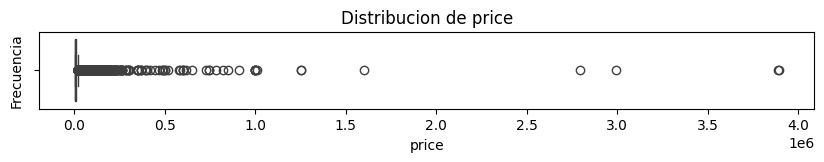

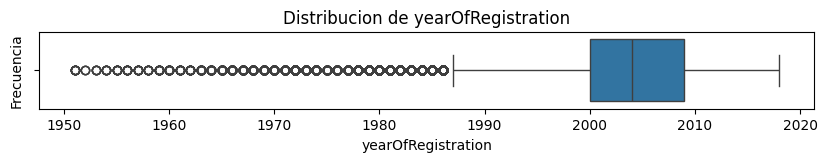

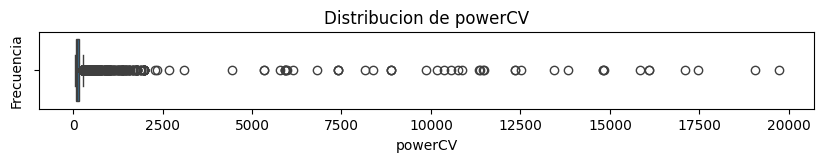

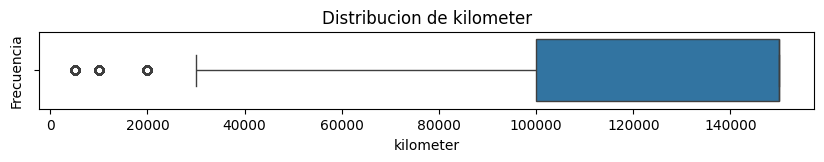

 
----------- Estamos analizando la columna: 'fuelType' -----------

Valores únicos: ['petrol' 'diesel' 'unknown' 'lpg' 'other' 'hybrid' 'cng' 'electro']

Frecuencias de los valores únicos de las categorías:


fuelType
petrol     150553
diesel      79934
unknown      9637
lpg          3497
cng           425
hybrid        220
electro        41
other          34
Name: count, dtype: int64

Countplots de las columnas categóricas:

La columna name tiene demasiadas categorías: 143490




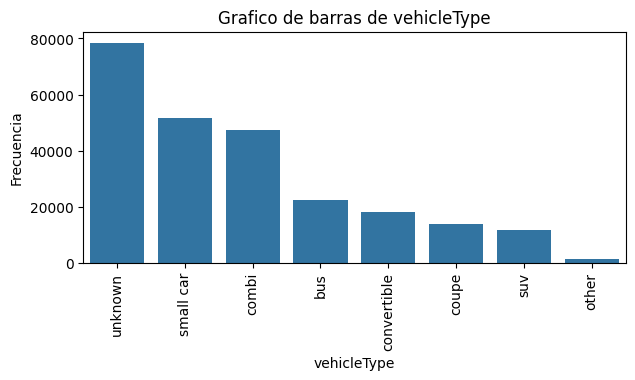

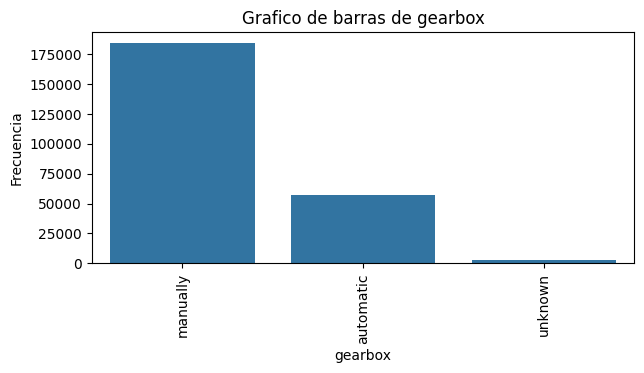

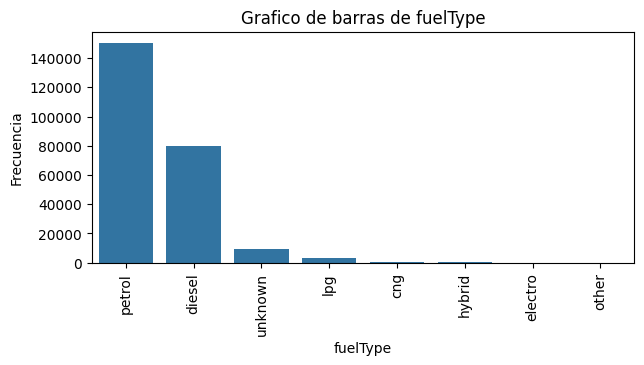

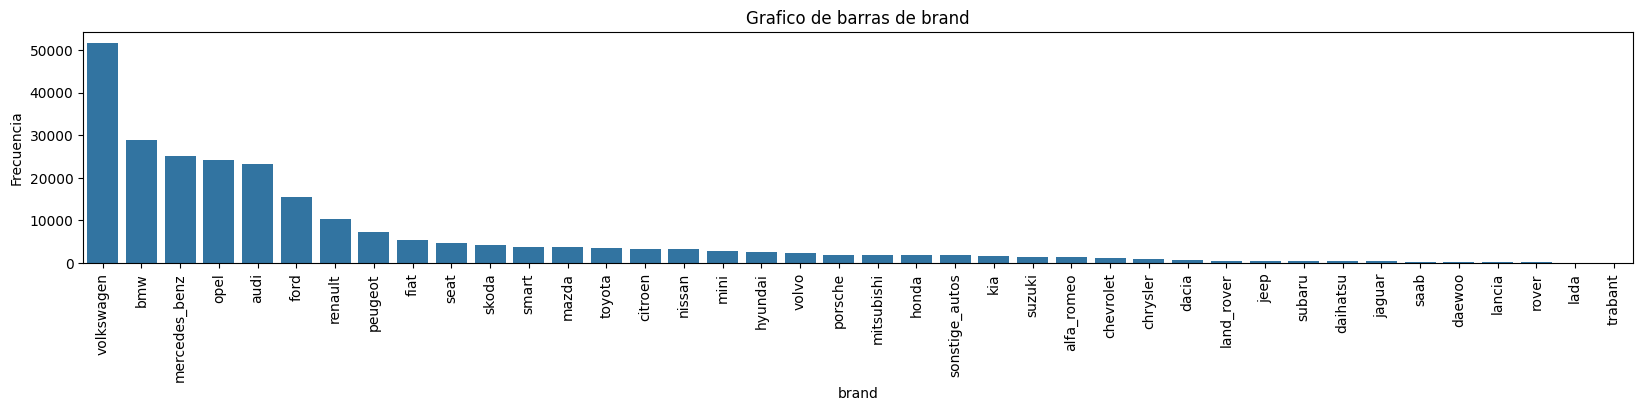

Histogramas:



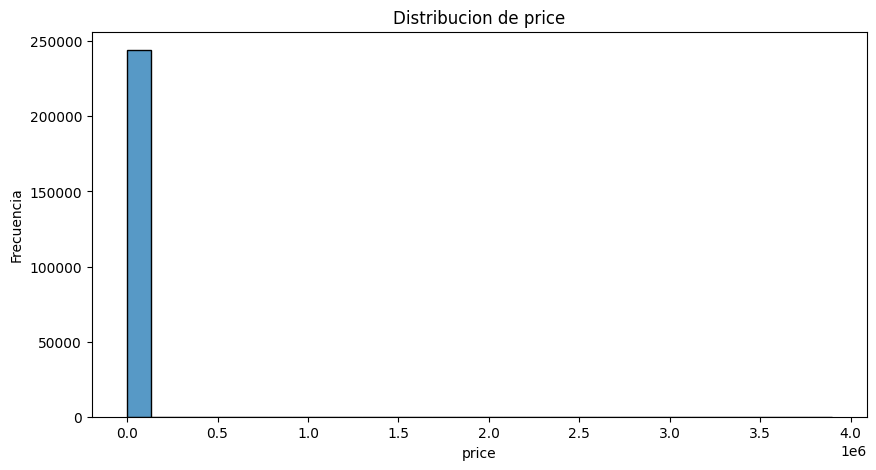

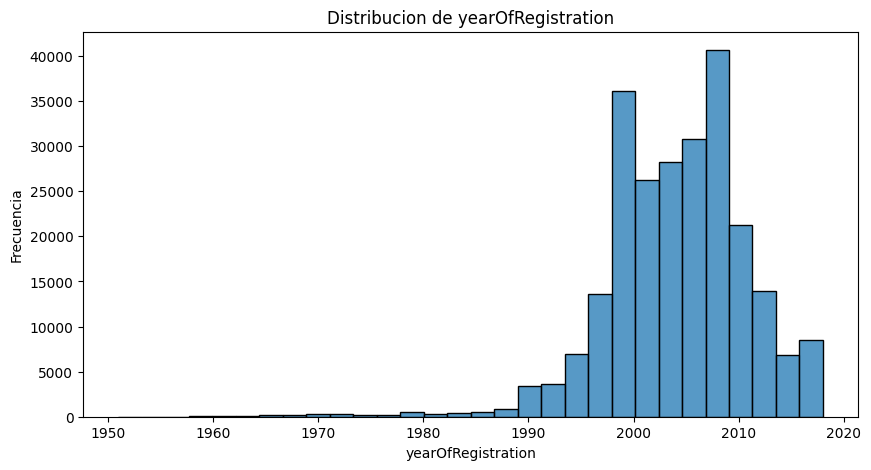

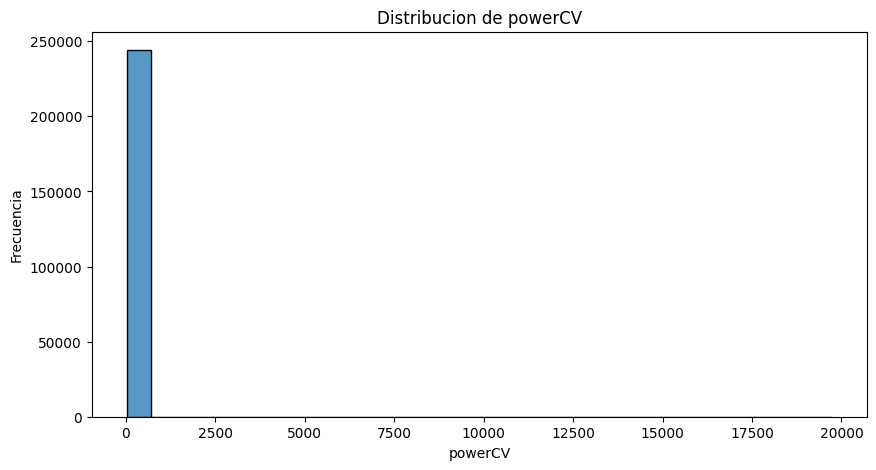

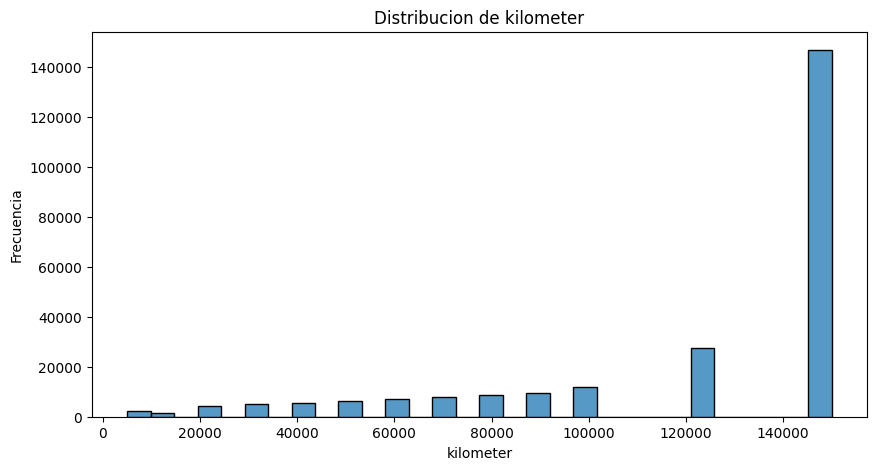

Vamos con los boxplots:



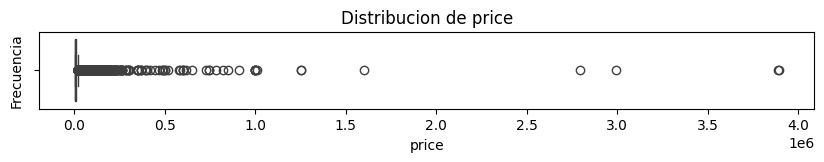

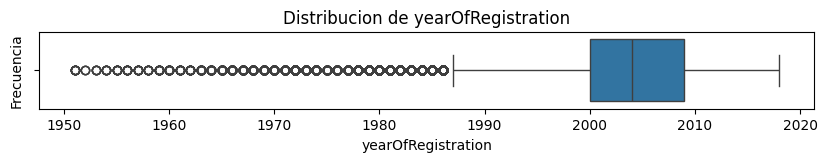

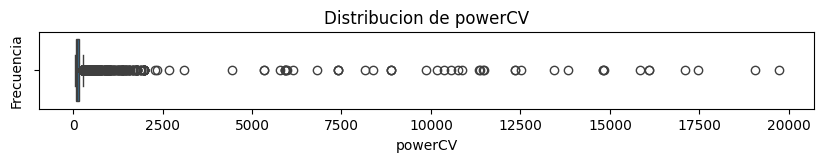

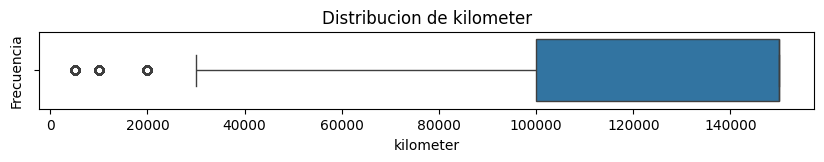

 
----------- Estamos analizando la columna: 'brand' -----------

Valores únicos: ['volkswagen' 'skoda' 'peugeot' 'mazda' 'nissan' 'renault' 'ford'
 'mercedes_benz' 'bmw' 'opel' 'seat' 'citroen' 'honda' 'fiat' 'mini'
 'smart' 'subaru' 'mitsubishi' 'audi' 'hyundai' 'alfa_romeo' 'kia'
 'lancia' 'porsche' 'toyota' 'chevrolet' 'dacia' 'suzuki' 'daihatsu'
 'sonstige_autos' 'chrysler' 'volvo' 'jaguar' 'daewoo' 'jeep' 'saab'
 'land_rover' 'rover' 'trabant' 'lada']

Frecuencias de los valores únicos de las categorías:


brand
volkswagen        51598
bmw               28879
mercedes_benz     25172
opel              24066
audi              23230
ford              15576
renault           10251
peugeot            7221
fiat               5454
seat               4772
skoda              4310
smart              3727
mazda              3695
toyota             3493
citroen            3295
nissan             3207
mini               2840
hyundai            2627
volvo              2285
porsche            1836
mitsubishi         1816
honda              1815
sonstige_autos     1788
kia                1775
suzuki             1533
alfa_romeo         1516
chevrolet          1229
chrysler            867
dacia               686
land_rover          582
jeep                563
subaru              472
daihatsu            444
jaguar              436
saab                373
daewoo              279
lancia              278
rover               225
lada                121
trabant               9
Name: count, dtype: int64

Countplots de las columnas categóricas:

La columna name tiene demasiadas categorías: 143490




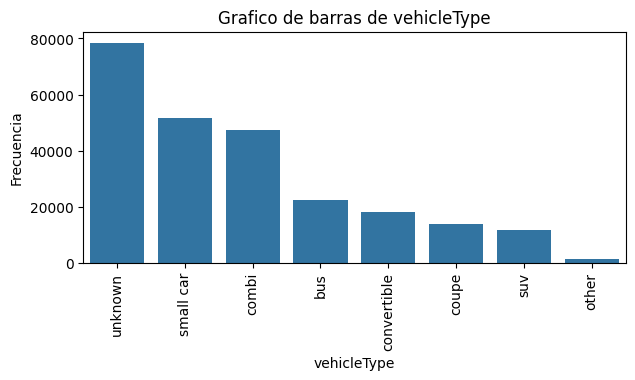

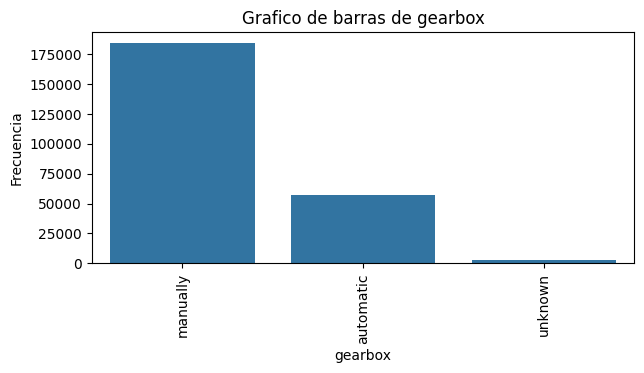

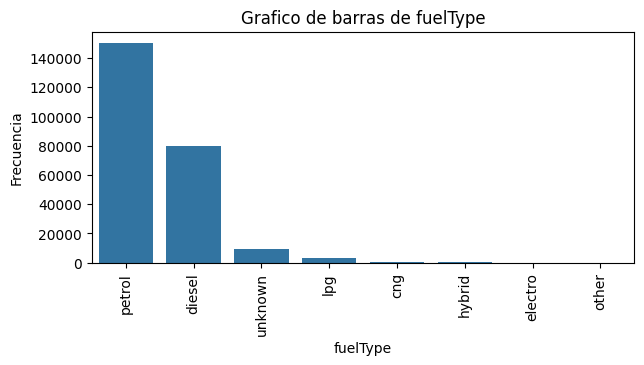

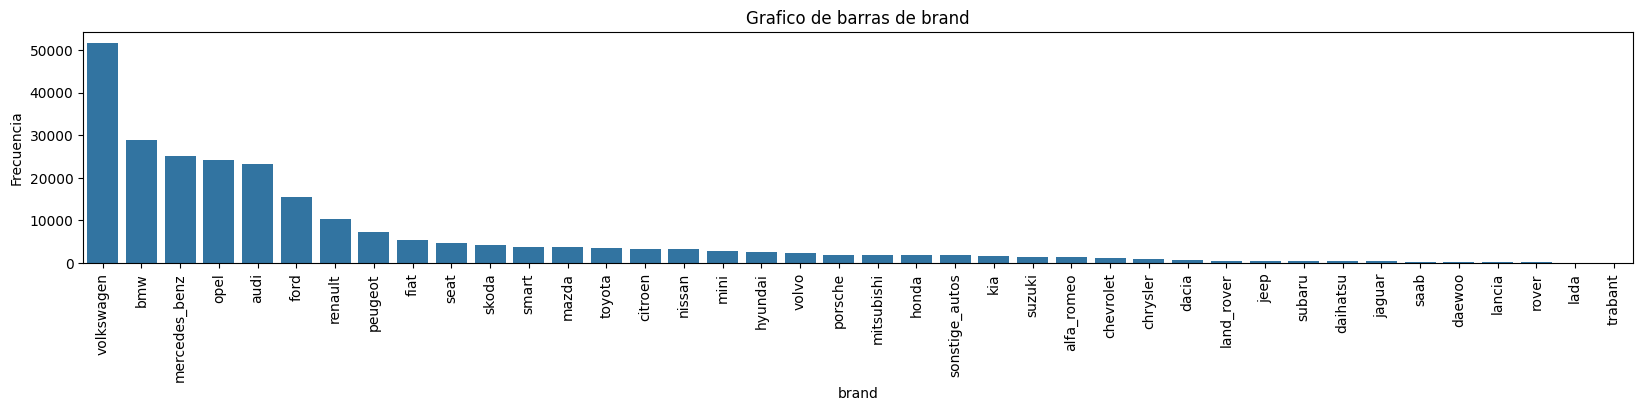

Histogramas:



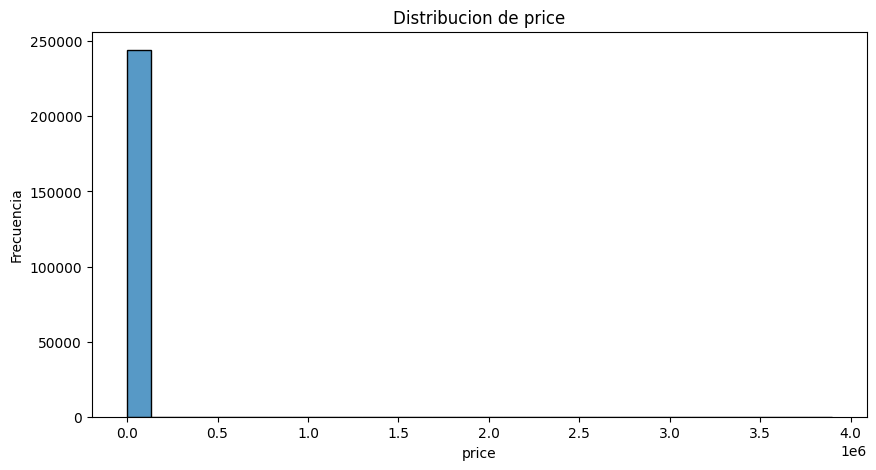

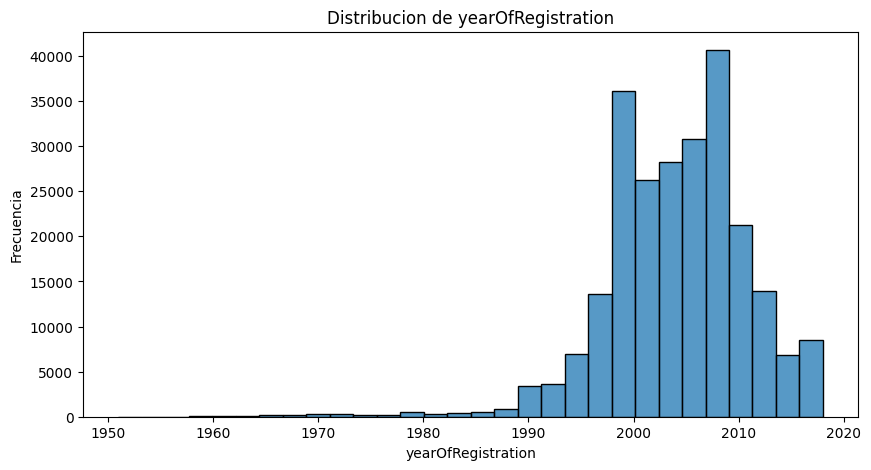

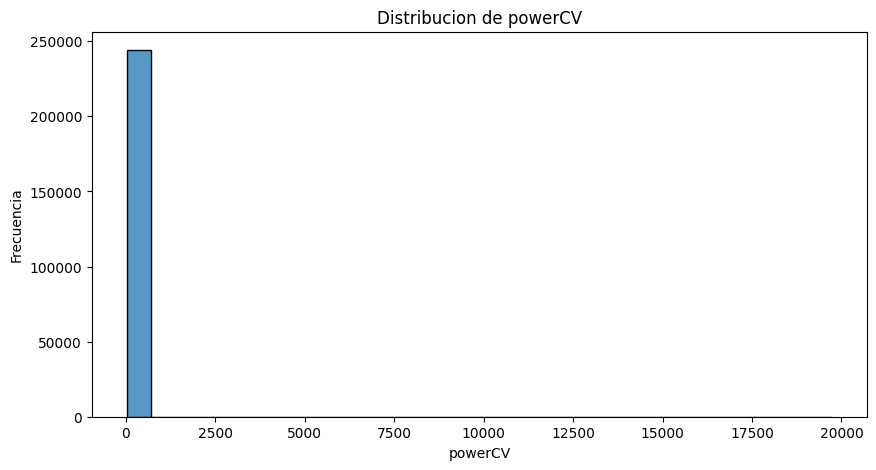

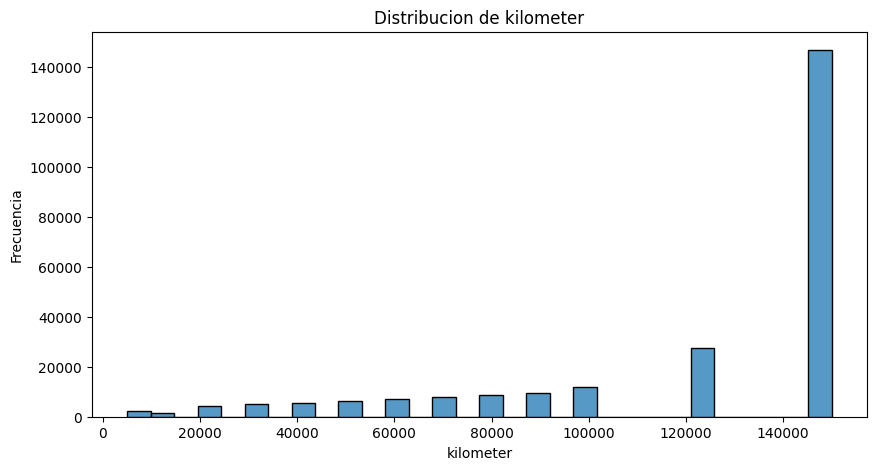

Vamos con los boxplots:



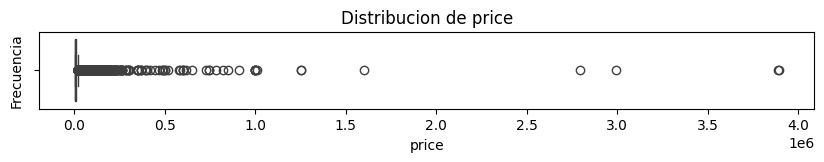

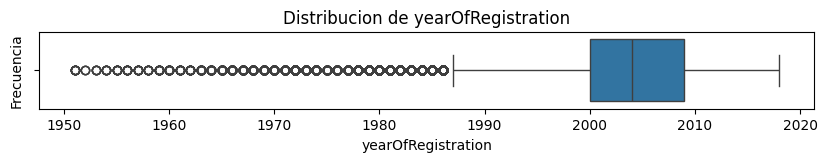

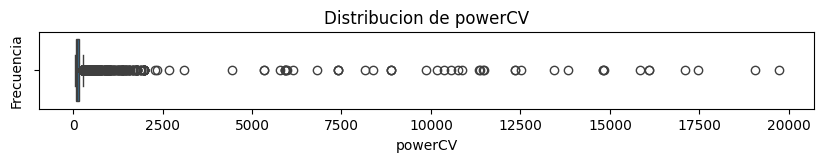

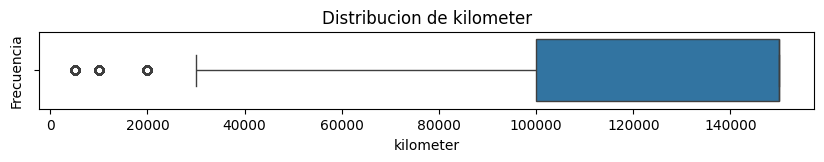

In [16]:
eda(df)

In [17]:
#Gráficos de barras para variables categóricas a SRC
""" for col in cat_cols:

  if df[col].nunique() > 200: #si es mayor no muestro grafico
      print(f"La columna {col} tiene demasiadas categorías: {df[col].nunique()}\n\n")
      continue

  num_categories = df [col] . nunique()
  width = max(7, num_categories * 0.5)
  height = 3

  plt. figure(figsize=(width, height))
  sns. countplot (x=df [col], order=df [col].value_counts ( ) . index)

  plt. title(f'Grafico de barras de {col}')
  plt.xlabel(col)
  plt. ylabel('Frecuencia')
  plt.xticks(rotation=90)

  plt. show() """

' for col in cat_cols:\n\n  if df[col].nunique() > 200: #si es mayor no muestro grafico\n      print(f"La columna {col} tiene demasiadas categorías: {df[col].nunique()}\n\n")\n      continue\n\n  num_categories = df [col] . nunique()\n  width = max(7, num_categories * 0.5)\n  height = 3\n\n  plt. figure(figsize=(width, height))\n  sns. countplot (x=df [col], order=df [col].value_counts ( ) . index)\n\n  plt. title(f\'Grafico de barras de {col}\')\n  plt.xlabel(col)\n  plt. ylabel(\'Frecuencia\')\n  plt.xticks(rotation=90)\n\n  plt. show() '

In [18]:
#Ajustamos dinámicamente de acuerdo al numero de columnas
#corr_matrix
#corr_matrix.shape

In [19]:
#Gráfico de calor para la matriz de correlación a SRC
""" import numpy as np

def matriz_correlacion(df):

    # Calcular la matriz de correlación
    corr_matrix = df.corr(numeric_only=True)

    # Crear la figura
    #plt.figure(figsize=(3, 3))
    plt.figure(figsize=corr_matrix.shape)
    # Crear una máscara para mostrar solo la parte triangular
    mask = np. triu(np.ones_like(corr_matrix, dtype=bool))
    # Graficar el mapa de calor
    sns. heatmap(corr_matrix,
    annot=True,
    vmin =- 1,
    vmax=1,
    mask=mask,
    cmap='cool')

    plt. show() """

" import numpy as np\n\ndef matriz_correlacion(df):\n\n    # Calcular la matriz de correlación\n    corr_matrix = df.corr(numeric_only=True)\n\n    # Crear la figura\n    #plt.figure(figsize=(3, 3))\n    plt.figure(figsize=corr_matrix.shape)\n    # Crear una máscara para mostrar solo la parte triangular\n    mask = np. triu(np.ones_like(corr_matrix, dtype=bool))\n    # Graficar el mapa de calor\n    sns. heatmap(corr_matrix,\n    annot=True,\n    vmin =- 1,\n    vmax=1,\n    mask=mask,\n    cmap='cool')\n\n    plt. show() "

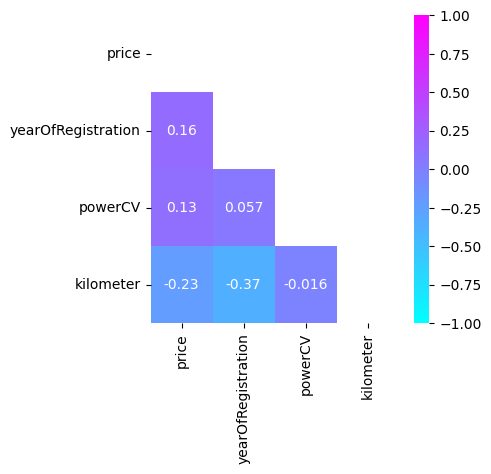

In [20]:
matriz_correlacion(df)